In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from infostop import Infostop
import tqdm
from multiprocessing import Pool
import contextily as cx
import geopandas as gpd
import sys
sys.path.insert(0, '/home/lpsha/s154446/fractality/')
from dgdc.dual_conti import get_dual_dir_con
from cities.download_cities import load_city
from shapely import STRtree
import powerlaw
from matplotlib.gridspec import GridSpecFromSubplotSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# os.cpu_count()



plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 150
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['axes.titlepad'] = 10
plt.rcParams['font.family'] = 'serif' # or 'sans-serif' or 'monospace'
plt.rcParams['font.serif'] = 'cmr10'
plt.rcParams['font.sans-serif'] = 'cmss10'
plt.rcParams['font.monospace'] = 'cmtt10'
plt.rcParams["axes.formatter.use_mathtext"] = True # to fix the minus signs

/home/lpsha/.conda/envs/infostop/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
MOVING_OUT_CSV = "/home/lpsha/s154446/fractality/mobility/moving_segments.csv"
STOPS_OUT_CSV = "/home/lpsha/s154446/fractality/mobility/stops_segments.csv"

df_stop = pd.read_csv(STOPS_OUT_CSV)
df_move = pd.read_csv(MOVING_OUT_CSV)

In [3]:
df_stop_u=df_stop.drop_duplicates(subset=['stopID','id']) #'stopID',
df_move_u=df_move.drop_duplicates(subset=['moveID','id','osmid']) #'stopID',

segment_counts = pd.DataFrame()

print("Unique segments in moving points:", df_move_u['osmid'].nunique())
print("Unique segments in stops:", df_stop_u['osmid'].nunique())

# Count occurrences in each DataFrame
move_counts = df_move_u['osmid'].value_counts().rename('n_move') 
stop_counts = df_stop_u['osmid'].value_counts().rename('n_stop')

# osmid -> degree mapping (same in both, so combine and drop duplicates)
degree_map = (
    pd.concat([df_move_u[['osmid', 'degree']], df_stop_u[['osmid', 'degree']]])
    .drop_duplicates('osmid')
    .set_index('osmid')['degree']
)

# Combine, filling missing osmids with 0
segment_counts = (
    pd.concat([move_counts, stop_counts, degree_map], axis=1)
    .fillna(0)
    .reset_index()
    .rename(columns={'index': 'osmid'})
)

segment_counts[['n_move', 'n_stop']] = segment_counts[['n_move', 'n_stop']].astype(int)
segment_counts['sum'] = segment_counts['n_move'] + segment_counts['n_stop']

t = 100

segment_counts=segment_counts[(segment_counts['n_stop'] > t) & (segment_counts['n_move'] > t)]
print("Segments with >N total points:", len(segment_counts))
segment_counts['frac_move'] = segment_counts['n_move'] / segment_counts['sum']
segment_counts['frac_stop'] = segment_counts['n_stop'] / segment_counts['sum']

Unique segments in moving points: 48032
Unique segments in stops: 22074
Segments with >N total points: 2236


In [38]:
f = 't50_a10'
path = '/home/lpsha/s154446/fractality/data/city_degrees/'+f+'/'
full_d = np.array([])
full_l = np.array([])
mean_4_length = np.array([])
median_4_length = np.array([])
mean_lessthan_4_length = np.array([])
median_lessthan_4_length = np.array([])

cities = os.listdir(path)
# --- Degree Distribution ---

for city in cities:
    d = np.load(path+city)
    full_d = np.append(full_d, d['degree'])
    full_l = np.append(full_l, d['length'])
    mean_4_length = np.append(mean_4_length, np.mean(d['length'][d['degree'] == 4]))
    median_4_length = np.append(median_4_length, np.median(d['length'][d['degree'] == 4]))
    mean_lessthan_4_length = np.append(mean_lessthan_4_length, np.mean(d['length'][d['degree'] < 4]))
    median_lessthan_4_length = np.append(median_lessthan_4_length, np.median(d['length'][d['degree'] < 4]))

lengths_by_degree_median = {}
lengths_by_degree_mean = {}
std_by_degree = {}

for k in range(1,100):
    data = full_l[full_d == k]
    if len(data) > 0:
        lengths_by_degree_median[k] = np.median(data)
        lengths_by_degree_mean[k] = np.mean(data)
        std_by_degree[k] = np.std(data)

In [ ]:
G = load_city("Copenhagen,_Denmark")
gdf_merged, _, _, _ = get_dual_dir_con(t_buffer=50, a_threshold=10, data=G, simplify_roundabout=True, enforce_degree2=False)

In [24]:
colors = ['blue','red']
L_size = 16

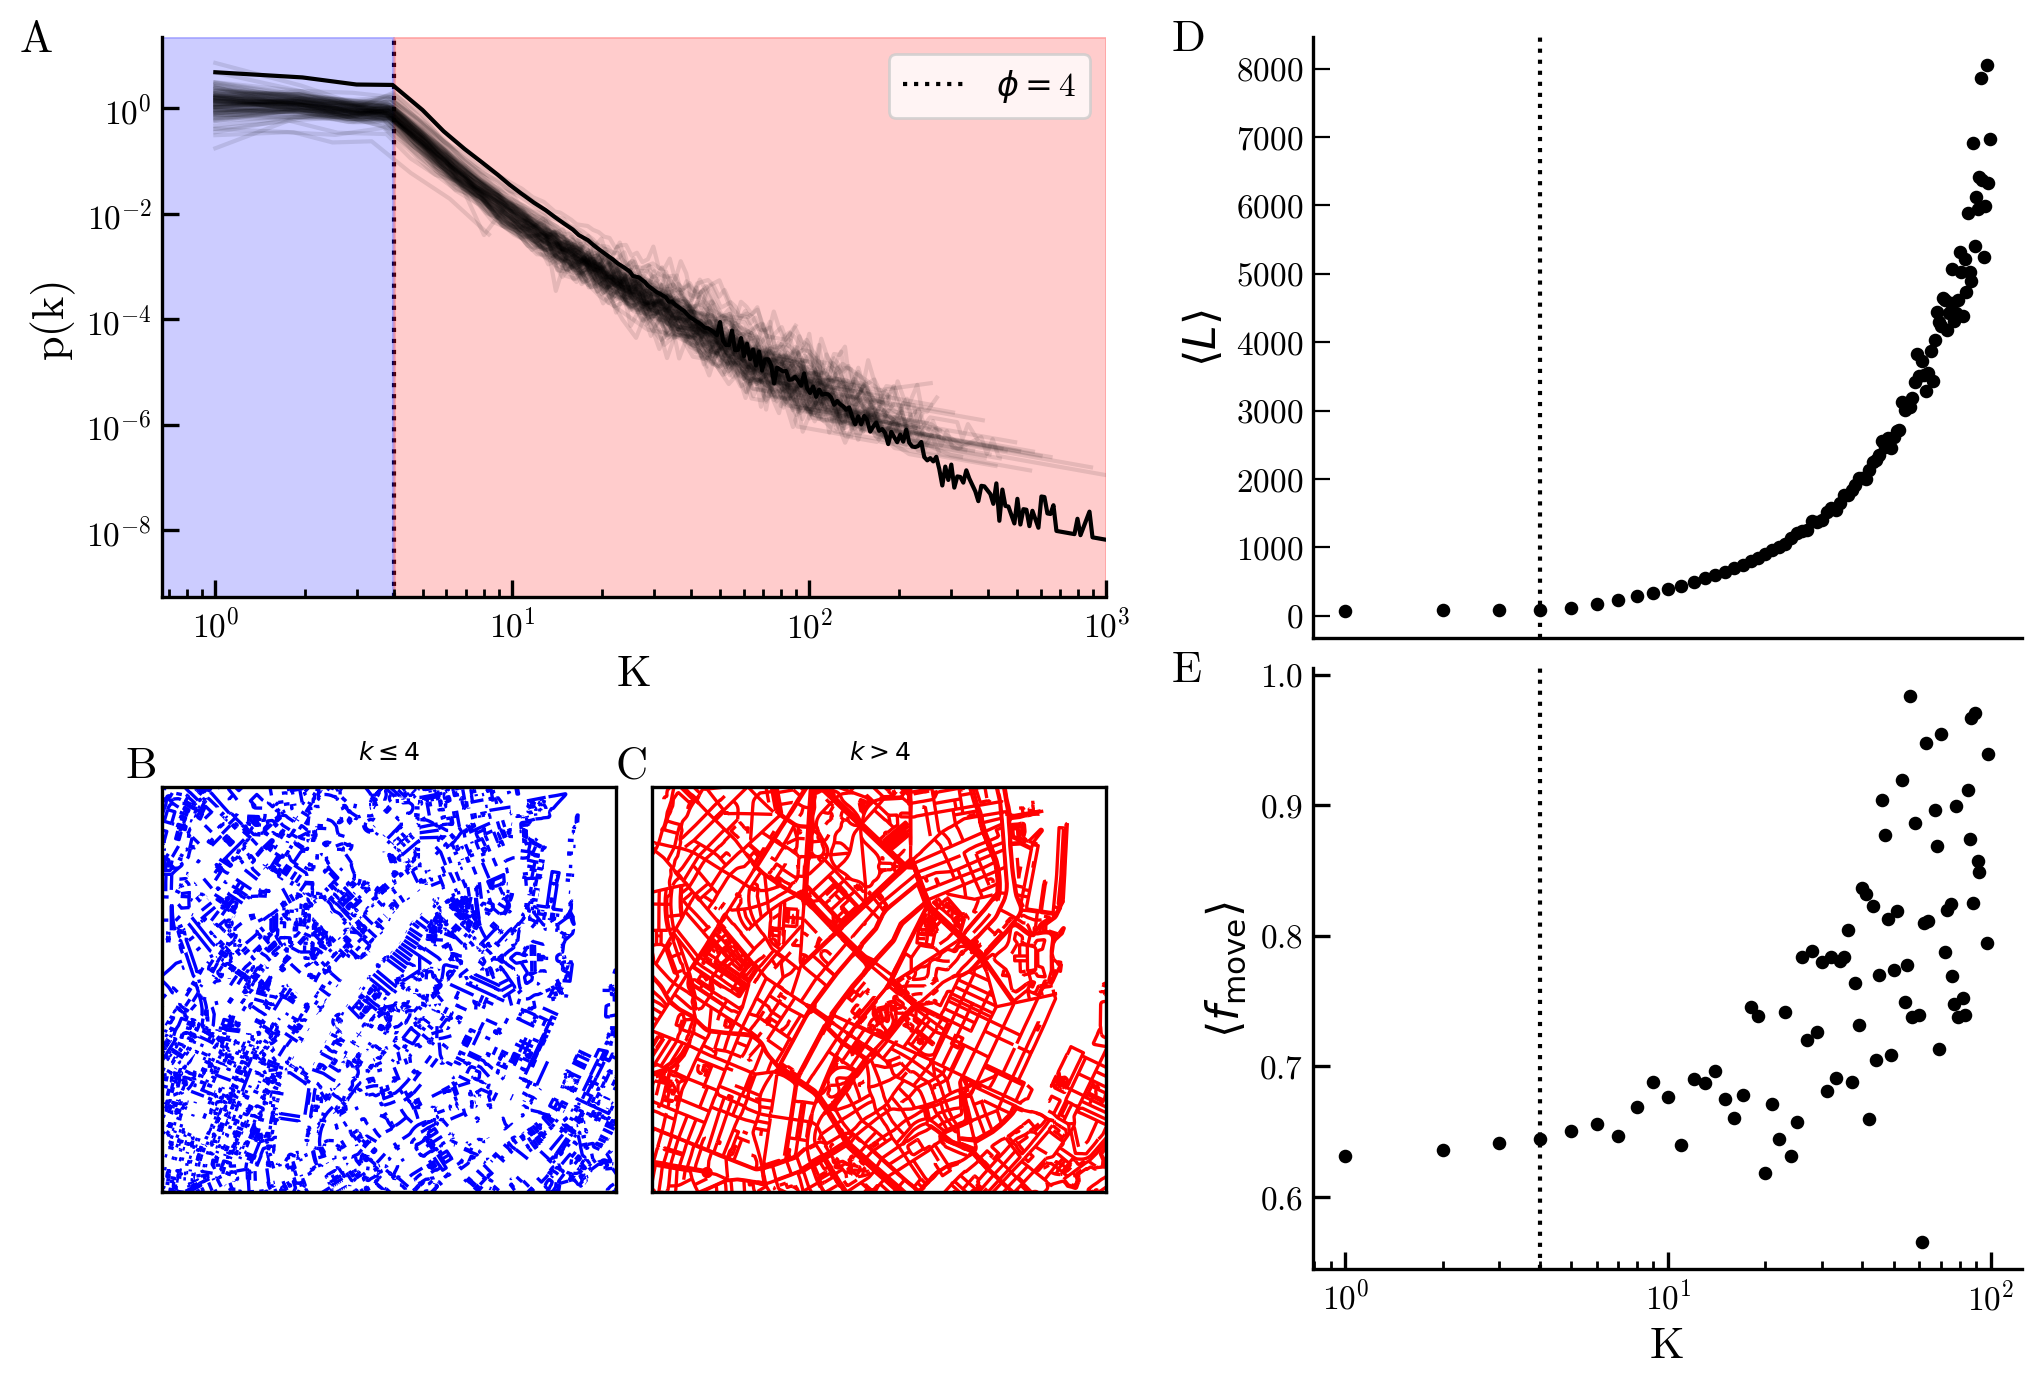

In [62]:
from matplotlib.gridspec import GridSpecFromSubplotSpec

fig = plt.figure(figsize=(12, 8), dpi=200)

gs = fig.add_gridspec(2, 2,
                      width_ratios=[1.2, 0.9],
                      height_ratios=[1, 1],
                      hspace=0.20, wspace=0.25)

gs_maps = gs[1, 0].subgridspec(1, 2, wspace=0.08)
gs_right = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[:, 1], hspace=0.05)

ax_deg  = fig.add_subplot(gs[0, 0])
ax_map1 = fig.add_subplot(gs_maps[0, 0])
ax_map2 = fig.add_subplot(gs_maps[0, 1])
ax1     = fig.add_subplot(gs_right[0])
ax2     = fig.add_subplot(gs_right[1], sharex=ax1)


# ── Degree distribution (A) ──────────────────────────────────────────────────
f = 't50_a10'
path = '/home/lpsha/s154446/fractality/data/city_degrees/' + f + '/'
full = np.array([])

cities = os.listdir(path)
for city in cities:
    d = np.load(path + city)
    d = d['degree']
    full = np.append(full, d)
    y, x = np.histogram(d, bins=np.logspace(0, np.log10(d.max()), len(np.unique(d))), density=True)
    x = x[:-1]
    x_nn = x[y != 0][:-1]
    y_nn = y[y != 0][:-1]
    ax_deg.plot(x_nn, y_nn, alpha=0.1, zorder=2, color='k')

y, x = np.histogram(full, bins=np.logspace(0, np.log10(full.max()), len(np.unique(full))), density=True)
x = x[:-1]
x_nn = x[y != 0][:-1]
y_nn = y[y != 0][:-1]
ax_deg.plot(x_nn, y_nn, alpha=1, zorder=2, color='k')

ax_deg.set_xscale('log')
ax_deg.set_yscale('log')
ax_deg.set_xlabel('K')
ax_deg.set_ylabel('p(k)')
ax_deg.spines['right'].set_visible(False)
ax_deg.spines['top'].set_visible(False)
ax_deg.xaxis.set_ticks_position('bottom')
ax_deg.yaxis.set_ticks_position('left')
ax_deg.xaxis.set_major_locator(plt.LogLocator(base=10.0))
ax_deg.yaxis.set_major_locator(plt.LogLocator(base=10.0))
ax_deg.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax_deg.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax_deg.yaxis.set_minor_formatter(plt.NullFormatter())
ax_deg.tick_params(which='major', length=6, width=1.2)
ax_deg.tick_params(which='minor', length=3, width=1.0)
ax_deg.axvline(4, color='k', linestyle='dotted', label=r'$\phi = $' + str(4), zorder=-1)
ax_deg.axvspan(xmin=0, xmax=3.95, color='blue', alpha=0.2, zorder=-1)
ax_deg.axvspan(xmin=4.01, xmax=1000, color='red', alpha=0.2, zorder=-1)
ax_deg.set_xlim(right=1000)
ax_deg.legend()
ax_deg.text(-0.15, 1.03, 'A', transform=ax_deg.transAxes, fontsize=L_size, fontweight='bold', va='top')


# ── Map panels (B, C) ────────────────────────────────────────────────────────
ps = 4
extent = gdf_merged.to_crs(3857).total_bounds
xmin, ymin, xmax, ymax = extent
x_center = (xmin + xmax) / 1.985
y_center = (ymin + ymax) / 2.001
x_range = (xmax - xmin) * 0.10
y_range = (ymax - ymin) * 0.10
x1_map = x_center - x_range / 2
x2_map = x_center + x_range / 2
y1_map = y_center - y_range / 2
y2_map = y_center + y_range / 2

gdf_merged[gdf_merged.degree <= ps].to_crs(3857).plot(color=colors[0], ax=ax_map1, linewidth=1.2)
gdf_merged[gdf_merged.degree > ps].to_crs(3857).plot(color=colors[1], ax=ax_map2, linewidth=1.2)

for ax_m, title, letter in zip([ax_map1, ax_map2], [r'$k \leq 4$', r'$k > 4$'], ['B', 'C']):
    ax_m.set_xlim(x1_map, x2_map)
    ax_m.set_ylim(y1_map, y2_map)
    ax_m.set_xticks([])
    ax_m.set_yticks([])
    ax_m.set_title(title, fontsize=9)
    ax_m.text(-0.08, 1.10, letter, transform=ax_m.transAxes, fontsize=L_size, fontweight='bold', va='top')


# ── Mean length (D) ──────────────────────────────────────────────────────────
# ax1.plot(list(lengths_by_degree_mean.keys()), list(lengths_by_degree_mean.values()), marker='None', color='k')
ax1.scatter(list(lengths_by_degree_mean.keys()), list(lengths_by_degree_mean.values()), color='k',s=15)
ax1.axvline(4, color='k', linestyle='dotted', zorder=-1)
ax1.set_ylabel(r'$\langle L \rangle$')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.yaxis.set_ticks_position('left')
ax1.text(-0.2, 1.03, 'D', transform=ax1.transAxes, fontsize=L_size, fontweight='bold', va='top')
plt.setp(ax1.get_xticklabels(), visible=False)
ax1.tick_params(axis='x', which='both', bottom=False)


# ── Frac move (E) ────────────────────────────────────────────────────────────
n = 100
frac_mean = []
for d in range(1, n):
    frac_mean.append(segment_counts[segment_counts.degree == d].frac_move.mean())

ax2.scatter(range(1, n), frac_mean, color='k', s=15)
ax2.axvline(4, color='k', linestyle='dotted', zorder=2)
ax2.set_xlabel('K')
ax2.set_ylabel(r'$\langle f_{\mathrm{move}} \rangle$')
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.yaxis.set_ticks_position('left')
ax2.set_xscale('log')
ax2.xaxis.set_major_locator(plt.LogLocator(base=10.0))
ax2.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax2.tick_params(which='major', length=6, width=1.2)
ax2.tick_params(which='minor', length=3, width=1.0)
ax2.xaxis.set_ticks_position('bottom')
ax2.text(-0.2, 1.03, 'E', transform=ax2.transAxes, fontsize=L_size, fontweight='bold', va='top')


plt.savefig('/home/lpsha/s154446/fractality/figures/figure1.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [51]:
def compute_ks(degree,min_range):
    distance = []
    ass = []
    for i_min in min_range:
        fit = powerlaw.Fit(degree,discrete=True,xmin=i_min)
        # a = fit.alpha
        xmin = fit.xmin
        x_fit = degree[degree>xmin]
        
        distance.append(fit.power_law.D)
        # ass.append(a) 

    return np.array(distance), min_range

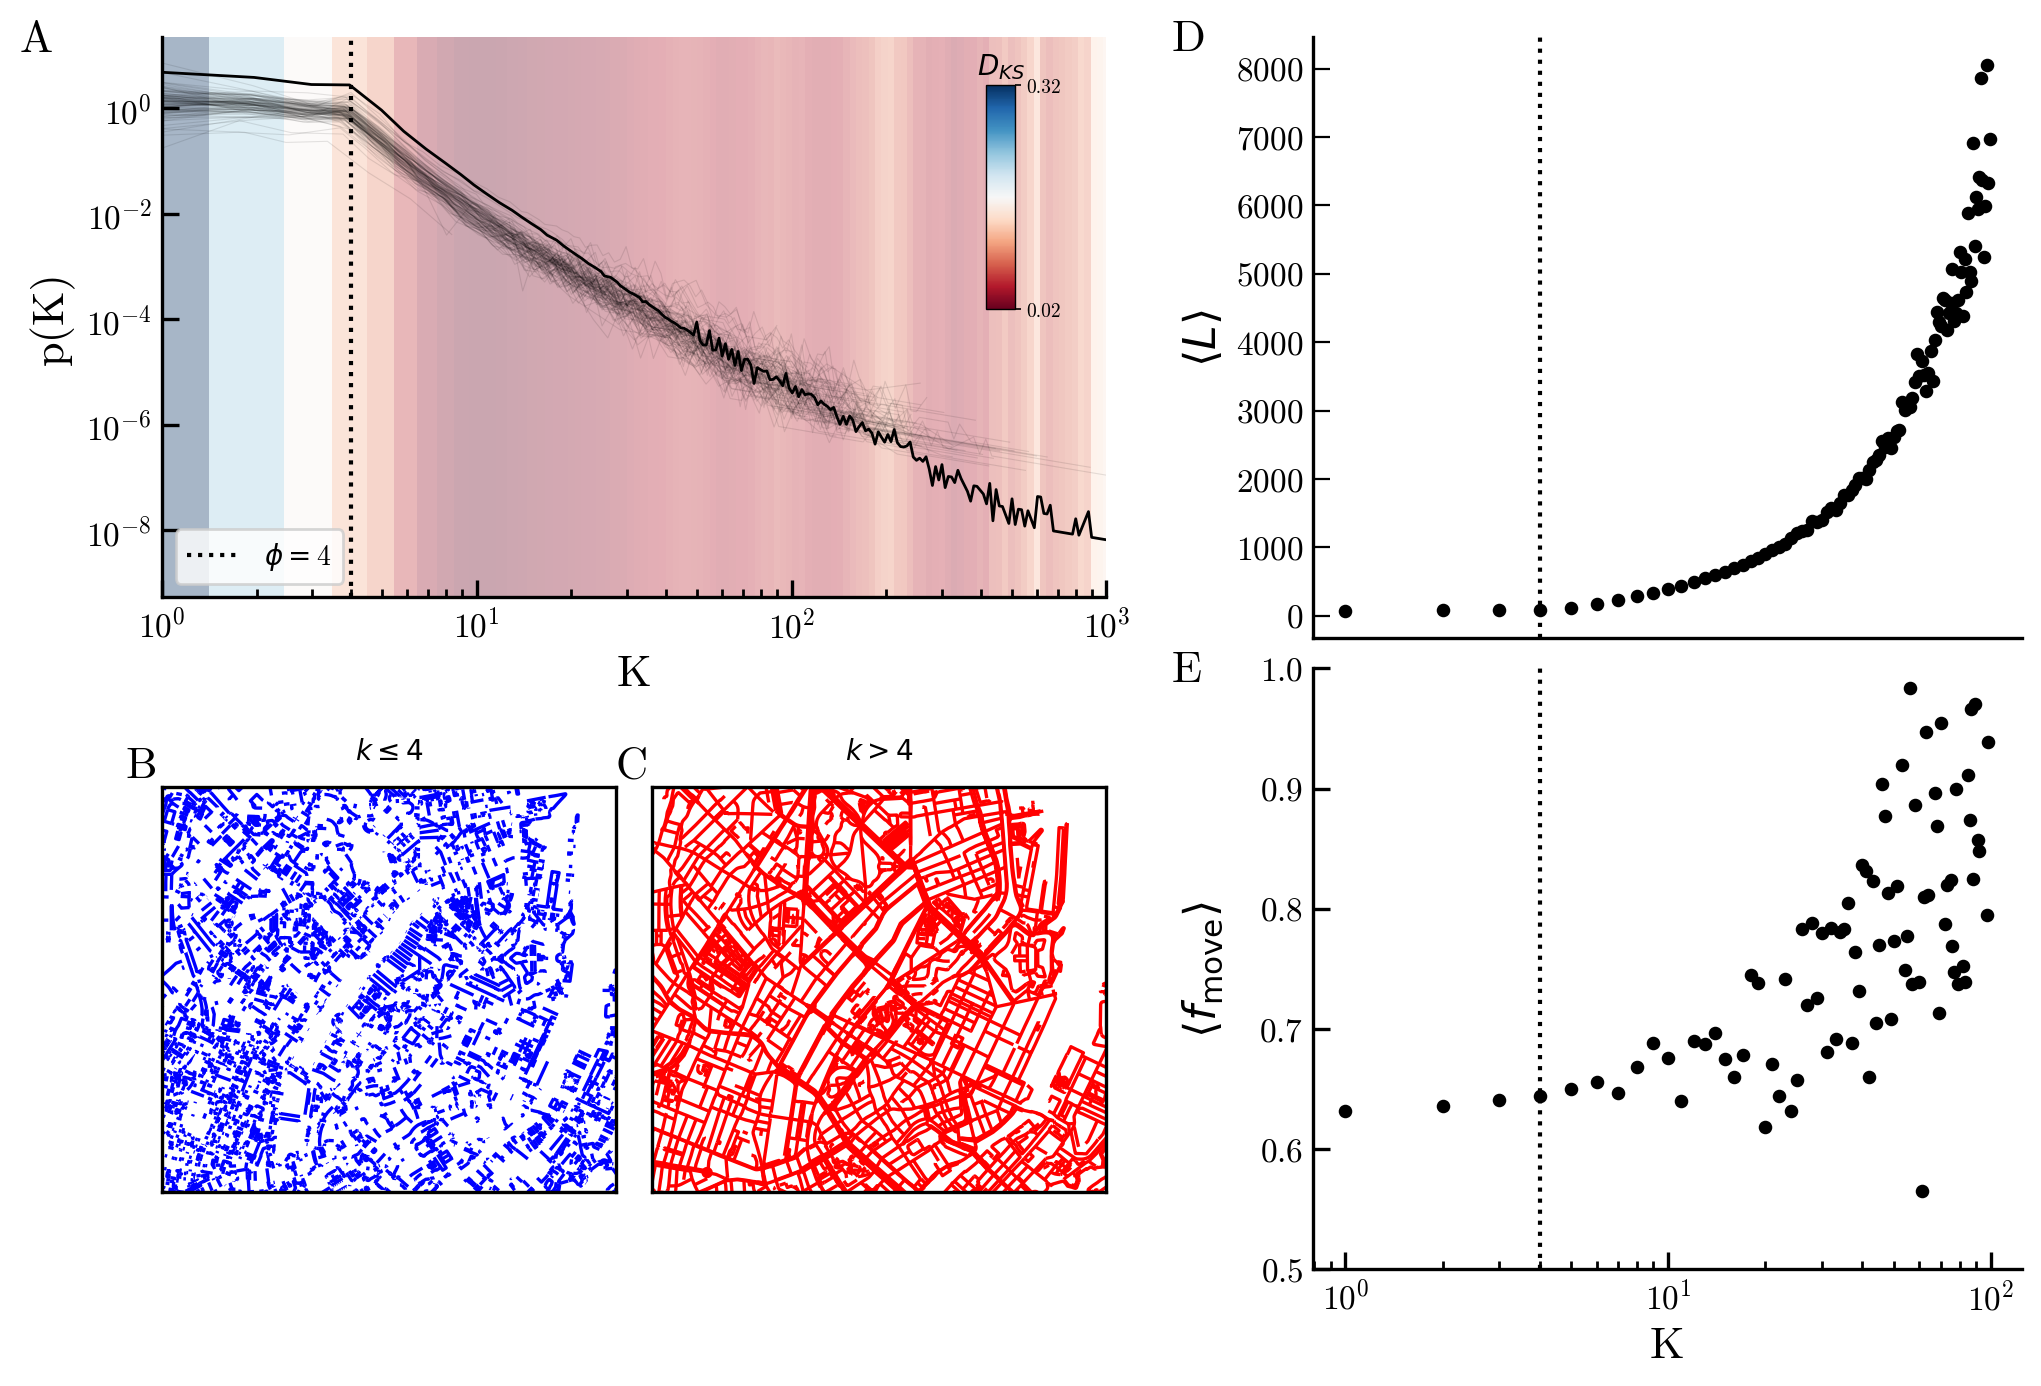

In [71]:
fig = plt.figure(figsize=(12, 8), dpi=200)

gs = fig.add_gridspec(2, 2,
                      width_ratios=[1.2, 0.9],
                      height_ratios=[1, 1],
                      hspace=0.20, wspace=0.25)

gs_maps = gs[1, 0].subgridspec(1, 2, wspace=0.08)
gs_right = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[:, 1], hspace=0.05)

ax_deg  = fig.add_subplot(gs[0, 0])
ax_map1 = fig.add_subplot(gs_maps[0, 0])
ax_map2 = fig.add_subplot(gs_maps[0, 1])
ax1     = fig.add_subplot(gs_right[0])
ax2     = fig.add_subplot(gs_right[1], sharex=ax1)


# ── Degree distribution with KS-colored background (A) ───────────────────────
f = 't50_a10'
path = '/home/lpsha/s154446/fractality/data/city_degrees/' + f + '/'
full = np.array([])

cities = os.listdir(path)
for city in cities:
    d = np.load(path + city)['degree']
    full = np.append(full, d)

    y, x = np.histogram(
        d, bins=np.logspace(0, np.log10(d.max()), len(np.unique(d))), density=True
    )
    x = x[:-1]
    x_nn = x[y != 0][:-1]
    y_nn = y[y != 0][:-1]
    ax_deg.plot(x_nn, y_nn, alpha=0.1, color='k', zorder=2, linewidth=0.4)

# --- KS distance on log-spaced xmins covering full plot range ---

# d_full = full[full != 0]
# xmins = np.unique(np.round(np.logspace(0, np.log10(1000), 200)).astype(int))
# xmins = xmins[xmins < d_full.max()]
# ks_dist, xmins_used = compute_ks(d_full, xmins)
# ks_dist = np.asarray(ks_dist)
# xmins_used = np.asarray(xmins_used, dtype=float)

# --- KS-colored background ---
ks_norm = (ks_dist - ks_dist.min()) / (ks_dist.max() - ks_dist.min())
cmap = plt.cm.RdBu          # low → red, high → blue

edges = np.concatenate([[1.0],
                        np.sqrt(xmins_used[:-1] * xmins_used[1:]),
                        [1000.0]])

for i in range(len(ks_norm)):
    ax_deg.axvspan(edges[i], edges[i + 1],
                   color=cmap(ks_norm[i]), alpha=0.35,
                   zorder=-1, linewidth=0)

# --- aggregate distribution ---
y, x = np.histogram(
    full, bins=np.logspace(0, np.log10(full.max()), len(np.unique(full))), density=True
)
x = x[:-1]
x_nn = x[y != 0][:-1]
y_nn = y[y != 0][:-1]
ax_deg.plot(x_nn, y_nn, color='k', zorder=2, linewidth=1.0)

# --- phi line ---
ax_deg.axvline(4, color='k', linestyle='dotted',
               label=r'$\phi = $' + str(4), zorder=3) #, linewidth=0.8

# --- axes / styling ---
ax_deg.set_xscale('log')
ax_deg.set_yscale('log')
ax_deg.set_xlabel('K')
ax_deg.set_ylabel('p(K)')
ax_deg.set_xlim(left=1, right=1000)
ax_deg.spines['right'].set_visible(False)
ax_deg.spines['top'].set_visible(False)
ax_deg.xaxis.set_ticks_position('bottom')
ax_deg.yaxis.set_ticks_position('left')
ax_deg.xaxis.set_major_locator(plt.LogLocator(base=10.0))
ax_deg.yaxis.set_major_locator(plt.LogLocator(base=10.0))
ax_deg.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax_deg.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax_deg.yaxis.set_minor_formatter(plt.NullFormatter())
ax_deg.tick_params(which='major', length=6, width=1.2)
ax_deg.tick_params(which='minor', length=3, width=1.0)

# --- inset colorbar (Nature/Science style) ---
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=plt.Normalize(ks_dist.min(), ks_dist.max())
)
sm.set_array([])


# get parent axes position in figure coords
pos = ax_deg.get_position()
cb_w = 0.012
cb_h = pos.height * 0.40
cb_x = pos.x1 - 0.05      # nudge left from right edge
cb_y = pos.y1 - cb_h - 0.03

cax = fig.add_axes([cb_x, cb_y, cb_w, cb_h])
cbar = fig.colorbar(sm, cax=cax)

cbar = fig.colorbar(sm, cax=cax)
cbar.set_ticks([ks_dist.min(), ks_dist.max()])
cbar.set_ticklabels([f'{ks_dist.min():.2f}', f'{ks_dist.max():.2f}'])
cbar.outline.set_linewidth(0.5)
cax.tick_params(width=0.6, length=2, direction='out', labelsize=7, pad=2)
cax.set_title(r'$D_{KS}$', fontsize=10, pad=4)

ax_deg.legend(frameon=True, fontsize=10, loc='lower left')
ax_deg.text(-0.15, 1.03, 'A', transform=ax_deg.transAxes,
            fontsize=L_size, fontweight='bold', va='top')


# ── Map panels (B, C) ────────────────────────────────────────────────────────
ps = 4
extent = gdf_merged.to_crs(3857).total_bounds
xmin, ymin, xmax, ymax = extent
x_center = (xmin + xmax) / 1.985
y_center = (ymin + ymax) / 2.001
x_range = (xmax - xmin) * 0.10
y_range = (ymax - ymin) * 0.10
x1_map = x_center - x_range / 2
x2_map = x_center + x_range / 2
y1_map = y_center - y_range / 2
y2_map = y_center + y_range / 2

gdf_merged[gdf_merged.degree <= ps].to_crs(3857).plot(color=colors[0], ax=ax_map1, linewidth=1.2)
gdf_merged[gdf_merged.degree > ps].to_crs(3857).plot(color=colors[1], ax=ax_map2, linewidth=1.2)

for ax_m, title, letter in zip([ax_map1, ax_map2], [r'$k \leq 4$', r'$k > 4$'], ['B', 'C']):
    ax_m.set_xlim(x1_map, x2_map)
    ax_m.set_ylim(y1_map, y2_map)
    ax_m.set_xticks([])
    ax_m.set_yticks([])
    ax_m.set_title(title, fontsize=10)
    ax_m.text(-0.08, 1.10, letter, transform=ax_m.transAxes,
              fontsize=L_size, fontweight='bold', va='top')


# ── Mean length (D) ──────────────────────────────────────────────────────────
ax1.scatter(list(lengths_by_degree_mean.keys()), list(lengths_by_degree_mean.values()),
            color='k', s=15)
ax1.axvline(4, color='k', linestyle='dotted', zorder=-1)
ax1.set_ylabel(r'$\langle L \rangle$')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.yaxis.set_ticks_position('left')
ax1.text(-0.2, 1.03, 'D', transform=ax1.transAxes,
         fontsize=L_size, fontweight='bold', va='top')
plt.setp(ax1.get_xticklabels(), visible=False)
ax1.tick_params(axis='x', which='both', bottom=False)


# ── Frac move (E) ────────────────────────────────────────────────────────────
n = 100
frac_mean = []
for d in range(1, n):
    frac_mean.append(segment_counts[segment_counts.degree == d].frac_move.mean())

ax2.scatter(range(1, n), frac_mean, color='k', s=15)
ax2.axvline(4, color='k', linestyle='dotted', zorder=2)
ax2.set_xlabel('K')
ax2.set_ylabel(r'$\langle f_{\mathrm{move}} \rangle$')
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.yaxis.set_ticks_position('left')
ax2.set_xscale('log')
ax2.xaxis.set_major_locator(plt.LogLocator(base=10.0))
ax2.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax2.tick_params(which='major', length=6, width=1.2)
ax2.tick_params(which='minor', length=3, width=1.0)
ax2.xaxis.set_ticks_position('bottom')
ax2.text(-0.2, 1.03, 'E', transform=ax2.transAxes, fontsize=L_size, fontweight='bold', va='top')
ax2.set_ylim([0.5,1])


plt.savefig('/home/lpsha/s154446/fractality/figures/figure2.pdf',
            bbox_inches='tight', dpi=300,
            bbox_extra_artists=[cax])

fig.align_ylabels([ax1, ax2])

plt.show()